## Denoising Diffusion Probability Models (DDPM)


In [ ]:

from einops import rearrange


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision.transforms.functional

import numpy as np
import matplotlib.pyplot as plt

In [12]:
from huggingface_hub import login
login()

In [14]:
from datasets import load_dataset

ds = load_dataset("ILSVRC/imagenet-1k", streaming=True, trust_remote_code=True)

torch.Size([1, 3, 363, 817])
torch.Size([1, 3, 491, 500])
torch.Size([1, 3, 375, 500])
torch.Size([1, 3, 375, 500])
torch.Size([1, 3, 375, 500])
torch.Size([1, 3, 333, 500])
torch.Size([1, 3, 500, 221])
torch.Size([1, 3, 333, 500])
torch.Size([1, 3, 173, 288])
torch.Size([1, 3, 370, 500])
torch.Size([1, 3, 460, 640])


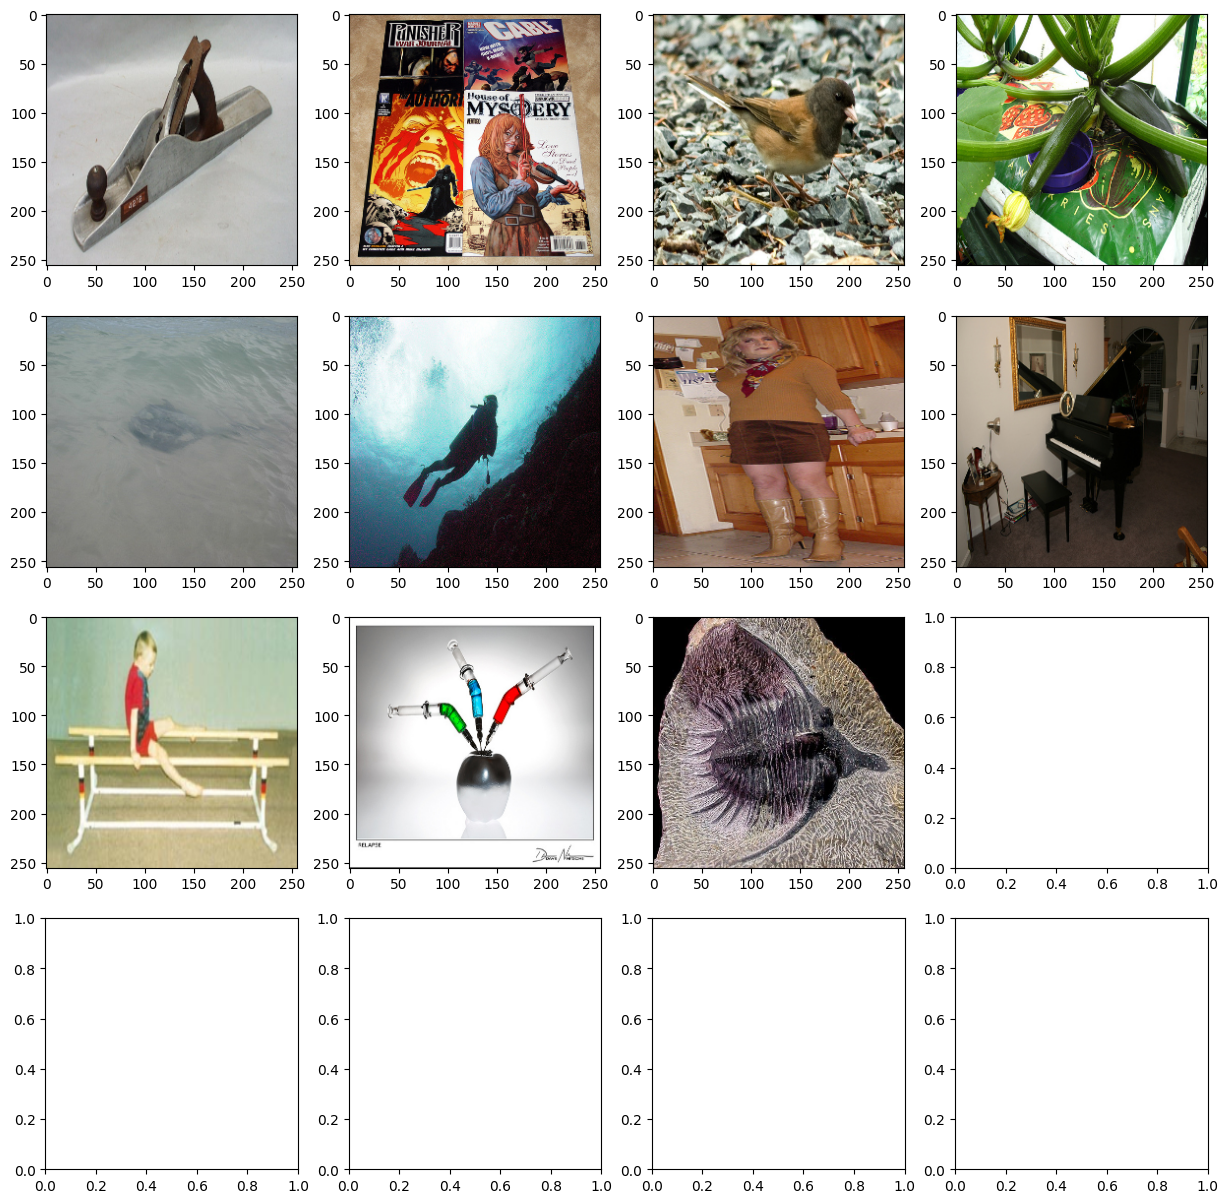

In [ ]:

fig, subplots = plt.subplots(4, 4, squeeze=False, figsize=(15,15))
subplots = subplots.flatten()

for i,x in enumerate(ds["train"]):
    im = torch.tensor(np.array(x["image"]))
    im = rearrange(im, "h w c -> 1 c h w")
    print(im.shape)
    new_shape = (256, 256)
    im = F.interpolate(im, new_shape, mode="bilinear")
    im = rearrange(im, "1 c h w -> h w c")
    subplots[i].imshow(im)

    if i == 15:
        break

## Model

In [ ]:

class TimeEmbedding(nn.Module):

    def __init__(self, d):
        super().__init__()
        self.d = d
        half = d // 2
        self.max_period = 10000
        self.thetas = torch.exp(-torch.log(self.max_period) * torch.arange(0, half, 1) / half)

        self.register_buffer('theta', self.thetas)
    
    def forward(self, t):

        if t.dim() == 0:

            res = torch.zeros(self.d)
            res[0::2] = torch.cos(self.thetas * t)
            res[1::2] = torch.sin(self.thetas * t)

        else:
            res = torch.zeros(t.shape[0], self.d)
            res[:, 0::2] = torch.cos(self.thetas * t.unsqueeze(-1))
            res[:, 1::2] = torch.sin(self.thetas * t.unsqueeze(-1))
        
        return res



class ResBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        self.norm1 = nn.BatchNorm2d(num_features=in_channels)
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()

        self.pe = TimeEmbedding(out_channels)
        self.pe_head = nn.Linear(out_channels, out_channels * 2)
        
        self.norm2 = nn.BatchNorm2d(num_features=out_channels)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()
        
        
    
    def forward(self, x, t):

        skip = x
        x = self.norm1(x)
        x = self.conv1(x)
        x = self.act1(x)

        pos_enc = self.pe(t)
        pos_enc = self.pe_head(pos_enc)

        gamma, beta = pos_enc[:self.out_channels], pos_enc[self.out_channels:]
        x = x * rearrange(gamma, "c -> b c h w", b=1, h=1, w=1) + rearrange(beta, "c -> b c h w", b=1, h=1, w=1)

        x = self.norm2(x)
        x = self.conv2(x)
        x = self.act2(x)
        return x + skip


class CropAndConcat(nn.Module):

    def forward(self, x: torch.Tensor, contracting_x: torch.Tensor):

        contracting_x = torchvision.transforms.functional.center_crop(contracting_x, (x.shape[2], x.shape[3]))
        x = torch.cat([x, contracting_x], dim=1)

        return x

class Upsample(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up_conv = nn.ConvTranspose2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=2,
            stride=2
        )

    def forward(self, x):
        return self.up_conv(x)


class UNet(nn.Module):

    def __init__(self, in_channels, out_channels):
        
        self.down_conv = nn.ModuleList([ResBlock(i, o) for (i, o) in
                                        [(in_channels, 64), (64, 128), (128, 256), (256, 512)]])
        self.down_sample = nn.ModuleList([nn.MaxPool2d(2) for _ in range(4)])

        self.middle_conv = ResBlock(512, 1024)

        self.up_sample = nn.ModuleList([Upsample(i, o) for (i, o) in 
                                        [(1024, 512), (512, 256), (256, 128), (128, 64)]])
        self.up_conv = nn.ModuleList([ResBlock(i, o) for (i, o) in
                                        [(1024, 512), (512, 256), (256, 128), (128, 64)]])

        self.crop_and_concat = CropAndConcat()

        self.final_conv = ResBlock(64, out_channels=out_channels)

    def forward(self, x, t):

        pass_through = []
        for i,conv in enumerate(self.down_conv):

            x = conv(x, t)
            pass_through.append(x)
            x = self.down_sample[i](x)
        
        x = self.middle_conv(x)

        for i,up in enumerate(self.up_sample):

            x = up(x, t)
            x = self.crop_and_concat(x, pass_through.pop())
            x = self.up_conv[i](x)
        
        x = self.final_conv(x)
        return x